# O Quadrante Mágico do Cinema: Rentabilidade por Género

**Objetivo:** Cruzar a análise de gêneros narrativos com os indicadores financeiros (Orçamento e ROI) para descobrir o modelo de negócio mais eficiente da indústria cinematográfica contemporânea.


### Perguntas de Negócio
1. **O Custo do Género:**  Quais são os gêneros mais caros de produzir e quais operam sob um modelo low-budget?
   
2. **A Eficiência do Retorno:** Que tipo de filme garante as maiores margens de lucro (ROI) para os estúdios, minimizando o risco financeiro?
   
3. **O Quadrante Mágico:** É possível encontrar um gênero que combine Alto Retorno Financeiro (ROI) com Alta Perceção Qualitativa (Boa Nota Média), ou Hollywood tem de escolher entre Lucro e Prestígio?

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas_datareader.data as web # Biblioteca para consumir APIs financeiras

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf
import src.view.plots._formatters as fmtt

---
## Caminho central para a base de dados relacional


In [2]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## O Custo do Género

In [3]:
query_budget_genres = """
    SELECT
        g.genres,
        c.budget
    FROM unified_media_genres as g
    INNER JOIN unified_media_catalog as c
        ON c.id = g.id
    WHERE g.media_type = 'Movie'
        AND c.budget > 0;
"""

df_b_g = dbc.execute_query(
    caminho_db=caminho_banco,
    alvo=query_budget_genres,
    eh_query=True
)

df_budget_genres = (
    df_b_g 
    .groupby('genres')
    .agg(
        quantidade_filmes=('budget', 'count'),
        budget_medio=('budget', 'mean'),
        budget_mediano=('budget', 'median')
    )
    .round(2)
    .reset_index()
)

for asc, nivel in {False: 'High', True: 'Low'}.items():
    display(
        tb.estilizar_tabela(
            df=df_budget_genres
            .sort_values('budget_mediano', ascending=asc)
            .set_index('genres'),
            qtd_linhas=20,
            caption=f'Custo de Produção por Gênero Cinematográfico ({nivel} Budget)'
        )
        .bar(subset=['quantidade_filmes'], color='#1D3557')
        .background_gradient(subset=['budget_medio'],cmap='YlGn')
        .background_gradient(subset=['budget_mediano'],cmap='Greens')
        .format({
            'quantidade_filmes': '{:,.0f}',
            'budget_medio': lambda x: '-' if pd.isna(x) else f'US$ {x:,.0f}',
            'budget_mediano': lambda x: '-' if pd.isna(x) else f'US$ {x:,.0f}'
        })
    )


Dados carregados via SQL! Formato: (21178, 2)


,quantidade_filmes,budget_medio,budget_mediano
genres,,,
Family,708,"US$ 47,511,412","US$ 30,000,000"
Animation,411,"US$ 48,653,886","US$ 28,000,000"
Adventure,"1,264","US$ 52,165,183","US$ 28,000,000"
Fantasy,717,"US$ 47,837,112","US$ 25,000,000"
Action,"2,071","US$ 37,514,060","US$ 18,000,000"
History,372,"US$ 23,955,079","US$ 14,867,000"
Mystery,631,"US$ 22,864,160","US$ 13,000,000"
Science Fiction,984,"US$ 35,982,555","US$ 13,000,000"
Crime,"1,232","US$ 22,472,272","US$ 12,125,000"


,quantidade_filmes,budget_medio,budget_mediano
genres,,,
Documentary,190,"US$ 2,368,443","US$ 500,000"
Gênero Não Identificado,33,"US$ 2,523,389","US$ 1,300,000"
Foreign,106,"US$ 3,754,736","US$ 2,000,000"
Horror,"1,227","US$ 9,657,205","US$ 3,500,000"
TV Movie,40,"US$ 5,136,225","US$ 3,750,000"
Western,136,"US$ 23,345,140","US$ 7,500,000"
Drama,"4,020","US$ 17,466,542","US$ 8,000,000"
Music,291,"US$ 15,443,326","US$ 10,000,000"
Romance,"1,431","US$ 18,268,939","US$ 10,000,000"


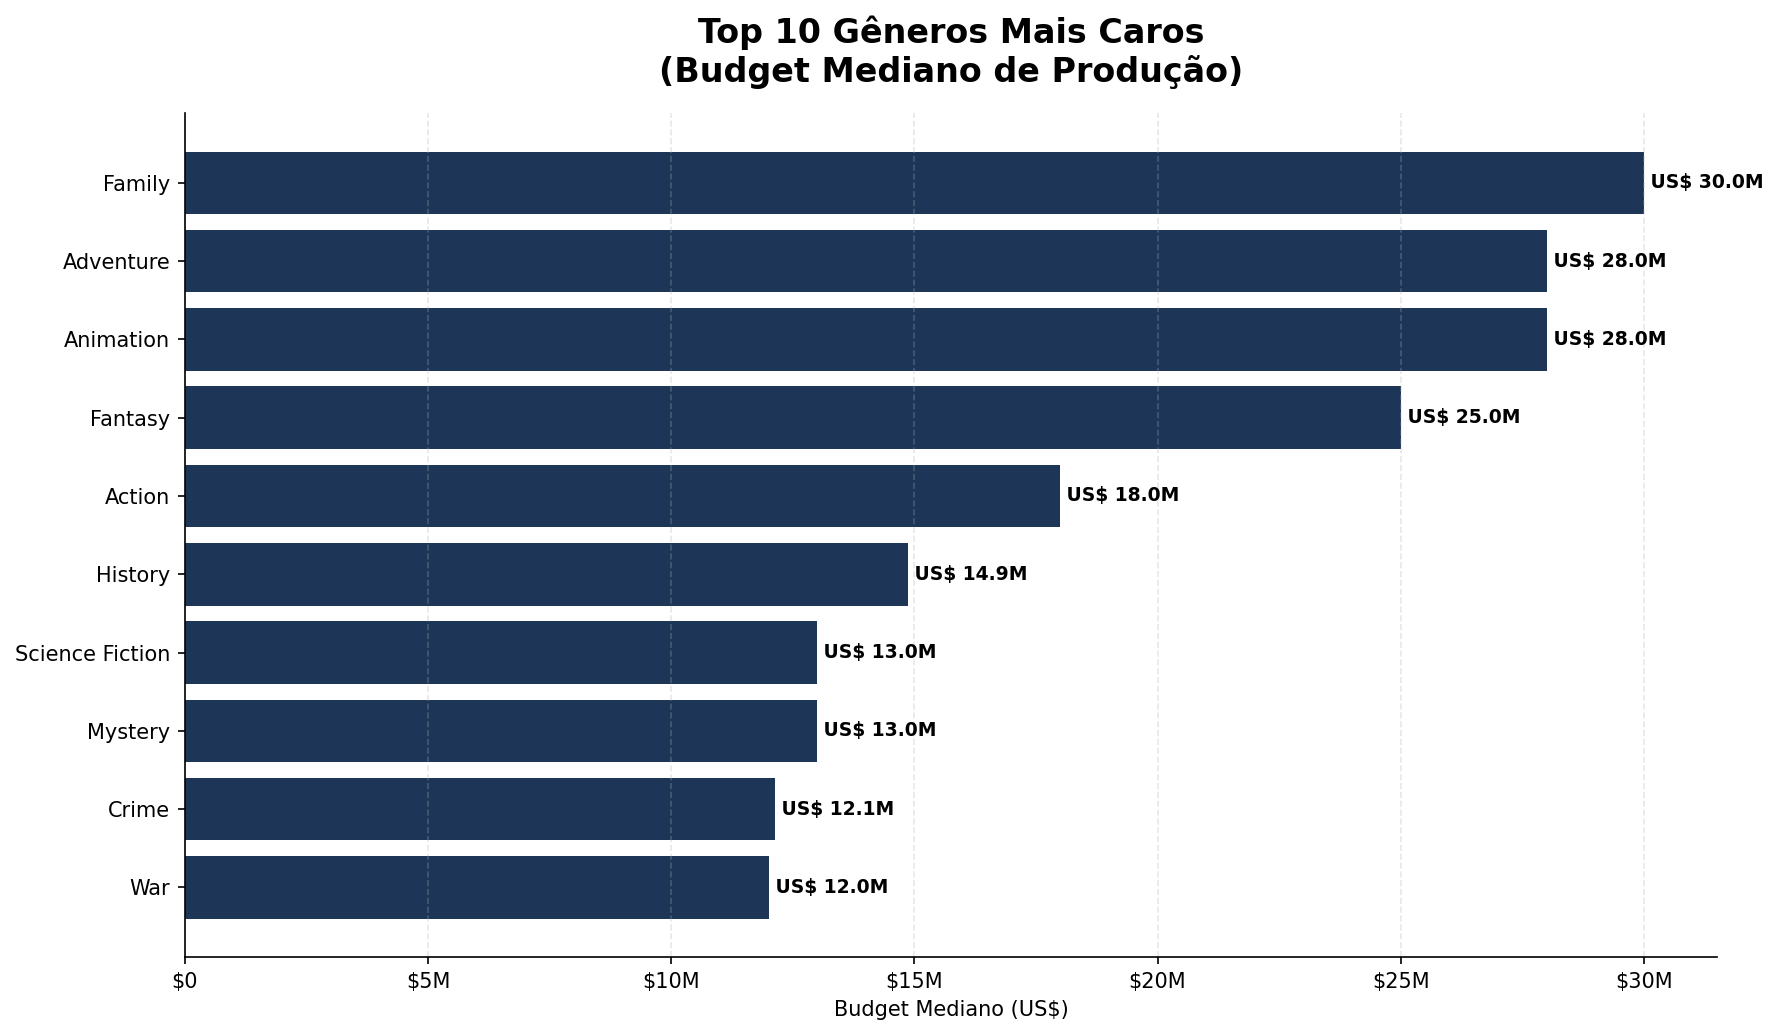

In [4]:
plt.figure(figsize=(12, 7), dpi=150)

df_high = (
    df_budget_genres
    .sort_values('budget_mediano', ascending=False)
    .head(10)
    .sort_values('budget_mediano')
)

bars = plt.barh(
    df_high['genres'],
    df_high['budget_mediano'],
    color='#1D3557'
)

for bar in bars:
    valor = bar.get_width()
    plt.text(
        valor,
        bar.get_y() + bar.get_height()/2,
        f' US$ {valor/1e6:.1f}M',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Top 10 Gêneros Mais Caros\n(Budget Mediano de Produção)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Budget Mediano (US$)')
plt.ylabel('')

plt.gca().xaxis.set_major_formatter( ticker.FuncFormatter(fmtt._formatar_dinheiro))

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

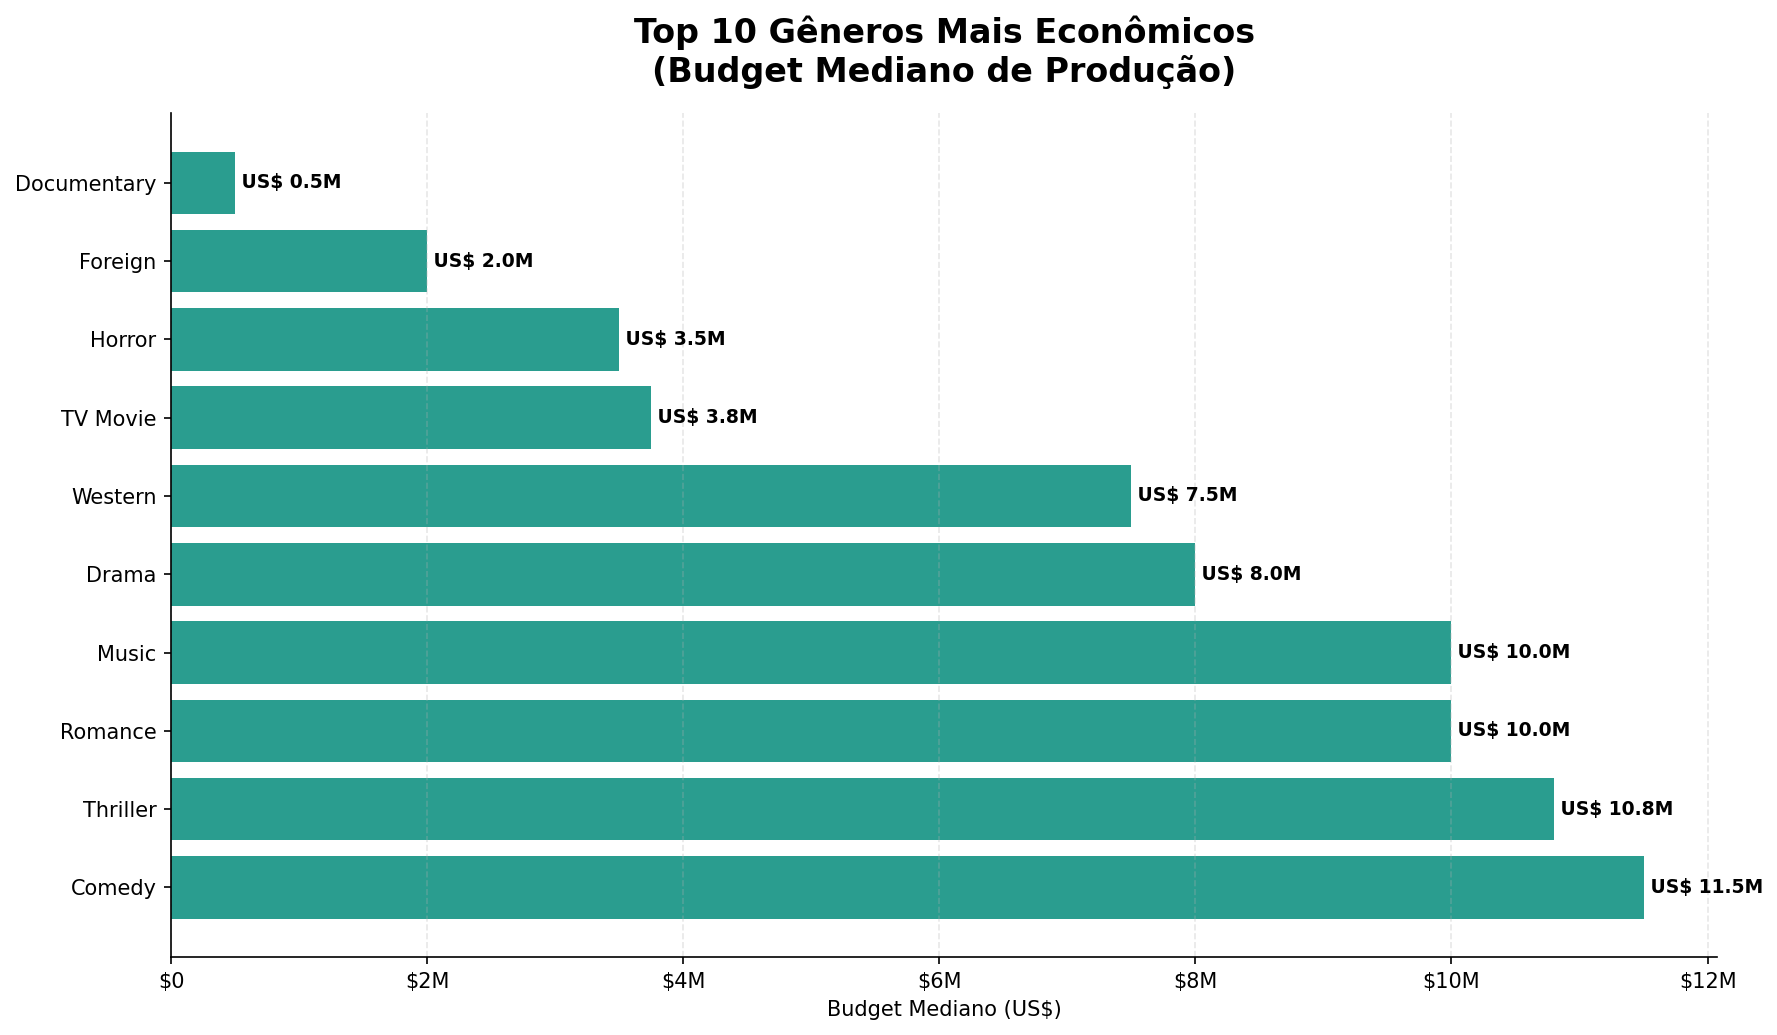

In [5]:
plt.figure(figsize=(12, 7), dpi=150)

df_low = (
    df_budget_genres[
        df_budget_genres['genres'] != 'Gênero Não Identificado'
    ]
    .sort_values('budget_mediano', ascending=True)
    .head(10)
)

bars = plt.barh(
    df_low['genres'],
    df_low['budget_mediano'],
    color='#2A9D8F'
)

for bar in bars:
    valor = bar.get_width()
    plt.text(
        valor,
        bar.get_y() + bar.get_height()/2,
        f' US$ {valor/1e6:.1f}M',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Top 10 Gêneros Mais Econômicos\n(Budget Mediano de Produção)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Budget Mediano (US$)')
plt.ylabel('')

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(fmtt._formatar_dinheiro))
plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### Salvando Nova Tabela 

In [6]:
dbc.save_db(
    df=df_budget_genres,
    pasta='../../data/processed',
    nome_banco='unified_media_catalog',
    nome_tabela='cinema_budget_genres'
)


Sucesso! Tabela 'cinema_budget_genres' criada no banco: 'unified_media_catalog.db'
